In [ ]:
import csv
import math
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# The deliverables/ folder contains algorithms.py, functions.py, optSolver.py
# directly, so add the notebook's own directory to sys.path.
HERE = Path.cwd()
ROOT = HERE
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import algorithms
import functions
import optSolver as _optSolver_module


def optSolver(problem, method, options):
    """Template-compatible solver entrypoint.

    This wrapper keeps the teacher's expected API name even if
    the implementation internally exposes Solver(...).
    """
    if hasattr(_optSolver_module, "optSolver"):
        return _optSolver_module.optSolver(problem, method, options)
    return _optSolver_module.Solver(problem, method, options)


print(f"Using solver from: {_optSolver_module.__file__}")

In [2]:
# Template-style problem container.
# It also tracks evaluation counts for Phase II reporting.
class Problem:
    def __init__(self, name, x0, func=None, grad=None, hess=None):
        self.name = name
        self.x0 = np.asarray(x0, dtype=float)
        self._func = func
        self._grad = grad
        self._hess = hess
        self.f_eval = 0
        self.g_eval = 0
        self.h_eval = 0

        # Optional fallback for quick single-problem debugging.
        if self._func is None or self._grad is None or self._hess is None:
            match name:
                case "Rosenbrock":
                    self._func = functions.Rosenbrock_func
                    self._grad = functions.Rosenbrock_grad
                    self._hess = functions.Rosenbrock_hess
                case _:
                    raise ValueError("problem not defined!!!")

    def compute_f(self, x):
        self.f_eval += 1
        return float(self._func(np.asarray(x, dtype=float)))

    def compute_g(self, x):
        self.g_eval += 1
        return np.asarray(self._grad(np.asarray(x, dtype=float)), dtype=float)

    def compute_H(self, x):
        self.h_eval += 1
        return np.asarray(self._hess(np.asarray(x, dtype=float)), dtype=float)


# Template-style method/options containers.
class Method:
    def __init__(self, name, **options):
        self.name = name
        self.options = options


class Options:
    def __init__(self, term_tol=1e-6, max_iterations=1e3, **kwargs):
        self.term_tol = term_tol
        self.max_iterations = max_iterations
        for key, value in kwargs.items():
            setattr(self, key, value)


# Build random SPD matrix with prescribed condition number.
def make_spd(n, kappa, rng):
    A = rng.standard_normal((n, n))
    Q_orth, _ = np.linalg.qr(A)
    eigvals = np.geomspace(1.0, float(kappa), num=n)
    return Q_orth @ np.diag(eigvals) @ Q_orth.T


# Create all 12 required project problems with function/gradient/Hessian handles.
def build_problem_specs(seed=0):
    rng = np.random.default_rng(seed)
    specs = []

    # P1-P4: Quadratic family with varying dimension/conditioning.
    for name, n, kappa in [
        ("P1_quad_10_10", 10, 10),
        ("P2_quad_10_1000", 10, 1000),
        ("P3_quad_1000_10", 1000, 10),
        ("P4_quad_1000_1000", 1000, 1000),
    ]:
        Q = make_spd(n, kappa, rng)
        q = rng.uniform(-10.0, 10.0, size=n)
        x0 = rng.uniform(-10.0, 10.0, size=n)
        specs.append({"name": name, "x0": x0, "Q":Q, "q":q, "func": lambda x, Q=Q, q=q: functions.Quad_func(x, Q, q), "grad": lambda x, Q=Q, q=q: functions.Quad_grad(x, Q, q), "hess": lambda x, Q=Q, q=q: functions.Quad_Hess(x, Q, q)})

    # P5-P6: Quartic family.
    Q4 = np.array([[5.0, 1.0, 0.0, 0.5], [1.0, 4.0, 0.5, 0.0], [0.0, 0.5, 3.0, 0.0], [0.5, 0.0, 0.0, 2.0]])
    x0_q = np.array([np.cos(70.0), np.sin(70.0), np.cos(70.0), np.sin(70.0)])
    specs.append({"name": "P5_quartic_1e-4", "x0": x0_q, "func": lambda x: functions.Quartic_func(x, Q4, 1e-4), "grad": lambda x: functions.Quartic_grad(x, Q4, 1e-4), "hess": lambda x: functions.Quartic_hess(x, Q4, 1e-4)})
    specs.append({"name": "P6_quartic_1e4", "x0": x0_q, "func": lambda x: functions.Quartic_func(x, Q4, 1e4), "grad": lambda x: functions.Quartic_grad(x, Q4, 1e4), "hess": lambda x: functions.Quartic_hess(x, Q4, 1e4)})

    # P7-P8: Rosenbrock.
    specs.append({"name": "P7_rosenbrock_2", "x0": np.array([-1.2, 1.0]), "func": functions.Rosenbrock_func, "grad": functions.Rosenbrock_grad, "hess": functions.Rosenbrock_hess})
    x0_r100 = np.ones(100)
    x0_r100[0] = -1.2
    specs.append({"name": "P8_rosenbrock_100", "x0": x0_r100, "func": functions.Rosenbrock_func, "grad": functions.Rosenbrock_grad, "hess": functions.Rosenbrock_hess})

    # P9: Data fitting.
    specs.append({"name": "P9_datafit_2", "x0": np.array([1.0, 1.0]), "func": functions.Datafit_func, "grad": functions.Datafit_grad, "hess": functions.Datafit_hess})

    # P10-P11: Exponential family.
    x0_e10 = np.zeros(10)
    x0_e10[0] = 1.0
    specs.append({"name": "P10_exponential_10", "x0": x0_e10, "func": functions.Exponential_func, "grad": functions.Exponential_grad, "hess": functions.Exponential_hess})
    x0_e100 = np.zeros(100)
    x0_e100[0] = 1.0
    specs.append({"name": "P11_exponential_100", "x0": x0_e100, "func": functions.Exponential_func, "grad": functions.Exponential_grad, "hess": functions.Exponential_hess})

    # P12: Genhumps.
    specs.append({"name": "P12_genhumps_5", "x0": np.array([-506.2, 506.2, -506.2, 506.2, -506.2]), "func": functions.Genhumps_func, "grad": functions.Genhumps_grad, "hess": functions.Genhumps_hess})
    return specs


PROBLEM_SPECS = build_problem_specs(seed=0)
print(f"Prepared {len(PROBLEM_SPECS)} problem specs.")

Prepared 12 problem specs.


In [ ]:
# Required methods listed in project description.
# We run all of them on every problem for the baseline comparison table.
METHODS = [
    "GradientDescent",
    "GradientDescentW",
    "Newton",
    "NewtonW",
    "TRNewtonCG",
    "TRSR1CG",
    "BFGS",
    "BFGSW",
    "DFP",
    "DFPW",
]

# Global stopping/control options used by all methods unless overridden.
# term_tol / max_iterations are required by the project description.
GLOBAL_OPTIONS = {
    "term_tol": 1e-6,
    "max_iterations": 1000,
    "c1_ls": 1e-4,
    "c2_ls": 0.9,
    "c1_tr": 0.25,
    "c2_tr": 0.75,
    "term_tol_CG": 1e-6,
    "max_iterations_CG": 1000,
}

# Method-specific defaults used in the baseline benchmark table.
# These values are chosen to be stable across the provided problem set.
METHOD_DEFAULTS = {
    "GradientDescent": {"alpha0": 1.0, "tau": 0.5, "c1_ls": 1e-4},
    "GradientDescentW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
    "Newton": {"alpha0": 1.0, "tau": 0.5, "c1_ls": 1e-4},
    "NewtonW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
    "TRNewtonCG": {"c1_tr": 0.25, "c2_tr": 0.75, "gamma1_tr": 0.25, "gamma2_tr": 2.0, "initial_trust_radius": 1.0, "term_tol_CG": 1e-6, "max_iterations_CG": 1000},
    "TRSR1CG": {"c1_tr": 0.25, "c2_tr": 0.75, "gamma1_tr": 0.25, "gamma2_tr": 2.0, "initial_trust_radius": 1.0, "term_tol_CG": 1e-6, "max_iterations_CG": 1000},
    "BFGS": {"alpha0": 1.0, "tau": 0.5, "c1_ls": 1e-4},
    "BFGSW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
    "DFP": {"alpha0": 1.0, "tau": 0.5, "c1_ls": 1e-4},
    "DFPW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
}


# Run one (problem, method) experiment and collect report metrics.
def run_one_experiment(problem_spec, method_name, method_options=None, global_options=None):
    method_options = method_options or {}
    global_options = global_options or GLOBAL_OPTIONS

    # Build template-style objects expected by optSolver(...).
    problem = Problem(
        name=problem_spec["name"],
        x0=problem_spec["x0"],
        func=problem_spec["func"],
        grad=problem_spec["grad"],
        hess=problem_spec["hess"],
    )
    method = Method(method_name, **method_options)
    options = Options(**global_options)

    # Track wall-clock runtime for CPU-time comparisons.
    t0 = time.perf_counter()
    status = "ok"
    error_msg = ""
    x_final = None
    f_final = np.nan
    f_hist = []

    # Solver returns x, f, and iteration history in this project version.
    try:
        x_final, f_final, f_hist, alpha_hist = optSolver(problem, method, options)
    except Exception as exc:
        # Keep the run in the table even if it fails.
        status = "fail"
        error_msg = str(exc)

    # Post-process scalar metrics required by summary reporting.
    cpu_sec = time.perf_counter() - t0
    iterations = max(len(f_hist) - 1, 0)
    grad_inf = np.nan
    if status == "ok" and x_final is not None:
        # Re-evaluate gradient at the final point for termination-quality reporting.
        grad_inf = np.linalg.norm(problem.compute_g(x_final), ord=np.inf)

    return {
        "problem": problem_spec["name"],
        "method": method_name,
        "status": status,
        "iterations": int(iterations),
        "f_eval": int(problem.f_eval),
        "g_eval": int(problem.g_eval),
        "h_eval": int(problem.h_eval),
        "cpu_sec": float(cpu_sec),
        "f_final": float(f_final) if np.isfinite(f_final) else np.nan,
        "grad_inf": float(grad_inf) if np.isfinite(grad_inf) else np.nan,
        "error": error_msg,
        "f_hist": f_hist,
    }


# Baseline full benchmark: 12 problems x 10 methods.
# This loop generates the main Phase II comparison dataset.
results = []
for p in PROBLEM_SPECS:
    for m in METHODS:
        row = run_one_experiment(
            p,
            m,
            method_options=dict(METHOD_DEFAULTS.get(m, {})),
            global_options=GLOBAL_OPTIONS,
        )
        results.append(row)

print(f"Finished {len(results)} runs.")
print(f"Successful runs: {sum(r['status'] == 'ok' for r in results)} / {len(results)}")

# Export summary table used in report section "Summary of Results".
summary_csv = ROOT / "Table: Summary of Results.csv"
fieldnames = ["problem", "method", "status", "iterations", "f_eval", "g_eval", "h_eval", "cpu_sec", "f_final", "grad_inf", "error"]
with summary_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in results:
        # Exclude f_hist from CSV (list-type field is not convenient for tabular report).
        writer.writerow({k: r[k] for k in fieldnames})

print(f"Saved summary table to: {summary_csv}")

Finished 120 runs.
Successful runs: 120 / 120
Saved summary table to: /Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/codespace/phase2_summary_results.csv


/Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/codespace/functions.py:100: RuntimeWarning: overflow encountered in exp
  term2 = 0.1 * np.exp(-x[0])
/Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/codespace/functions.py:109: RuntimeWarning: overflow encountered in exp
  g[0] = (2 * expx / (denom**2)) - 0.1 * np.exp(-x[0])


In [4]:
# get the real minimum vlaue of f
def rebuild_quad_data(problem_name, seed=0):
    rng = np.random.default_rng(seed)

    quad_specs = [
        ("P1_quad_10_10", 10, 10),
        ("P2_quad_10_1000", 10, 1000),
        ("P3_quad_1000_10", 1000, 10),
        ("P4_quad_1000_1000", 1000, 1000),
    ]

    for name, n, kappa in quad_specs:
        Q = make_spd(n, kappa, rng)
        q = rng.uniform(-10.0, 10.0, size=n)
        _x0 = rng.uniform(-10.0, 10.0, size=n)

        if name == problem_name:
            return Q, q

    raise ValueError(f"Unknown quadratic problem: {problem_name}")


def get_f_star(problem_name):
    if problem_name in [
        "P1_quad_10_10",
        "P2_quad_10_1000",
        "P3_quad_1000_10",
        "P4_quad_1000_1000",
    ]:
        Q, q = rebuild_quad_data(problem_name, seed=0)
        return -0.5 * q @ np.linalg.solve(Q, q)

    elif "quartic" in problem_name:
        return 0.0
    elif "rosenbrock" in problem_name:
        return 0.0
    elif "datafit" in problem_name:
        return 0.0
    elif "exponential" in problem_name:
        return -0.9
    elif "genhumps" in problem_name:
        return 0.0
    else:
        raise ValueError(f"Unknown problem: {problem_name}")

,problem,method,status,iterations,f_eval,g_eval,h_eval,cpu_sec,f_final,grad_inf,error
0,P1_quad_10_10,GradientDescent,ok,44,149,150,0,0.002186,-71.42913,3.165100e-05,
1,P1_quad_10_10,GradientDescentW,ok,44,149,150,0,0.004413,-71.42913,3.165100e-05,
2,P1_quad_10_10,Newton,ok,1,2,3,1,0.000473,-71.42913,1.598721e-14,
3,P1_quad_10_10,NewtonW,ok,1,2,3,1,0.000190,-71.42913,1.598721e-14,
4,P1_quad_10_10,TRNewtonCG,ok,5,6,7,5,0.001038,-71.42913,8.881784e-15,
5,P1_quad_10_10,TRSR1CG,ok,10,11,12,0,0.001977,-71.42913,3.540217e-07,
6,P1_quad_10_10,BFGS,ok,16,25,26,0,0.001044,-71.42913,1.917529e-05,
7,P1_quad_10_10,BFGSW,ok,16,25,26,0,0.001268,-71.42913,1.917529e-05,
8,P1_quad_10_10,DFP,ok,16,22,23,0,0.001328,-71.42913,5.549135e-06,
9,P1_quad_10_10,DFPW,ok,16,22,23,0,0.000890,-71.42913,5.549135e-06,



Summary table (iterations):


method,BFGS,BFGSW,DFP,DFPW,GradientDescent,GradientDescentW,Newton,NewtonW,TRNewtonCG,TRSR1CG
problem,,,,,,,,,,
P10_exponential_10,19,23,1000,104,27,27,13,13,12,17
P11_exponential_100,10,6,10,6,21,18,13,13,13,18
P12_genhumps_5,59,51,1000,1000,189,218,69,60,103,135
P1_quad_10_10,16,16,16,16,44,44,1,1,5,10
P2_quad_10_1000,15,15,15,15,1000,1000,1,1,5,14
P3_quad_1000_10,59,59,106,106,43,43,1,1,8,27
P4_quad_1000_1000,345,345,232,232,1000,1000,1,1,9,219
P5_quartic_1e-4,3,3,3,3,2,2,2,2,3,3
P6_quartic_1e4,28,28,18,18,5,5,12,12,12,27


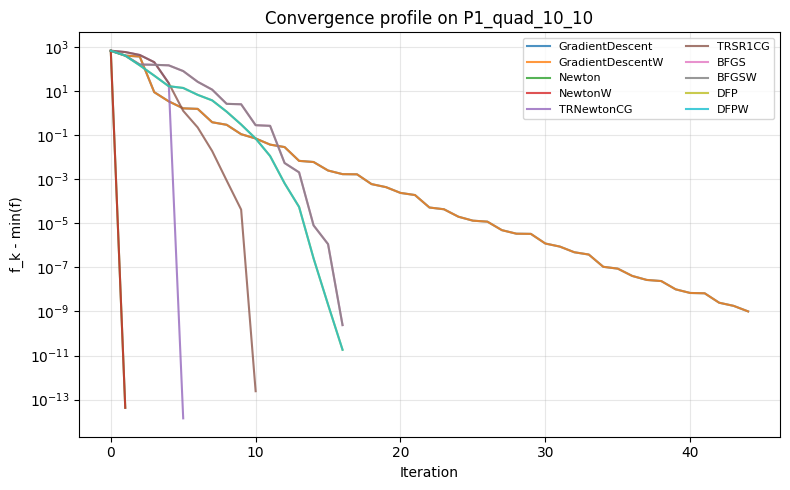

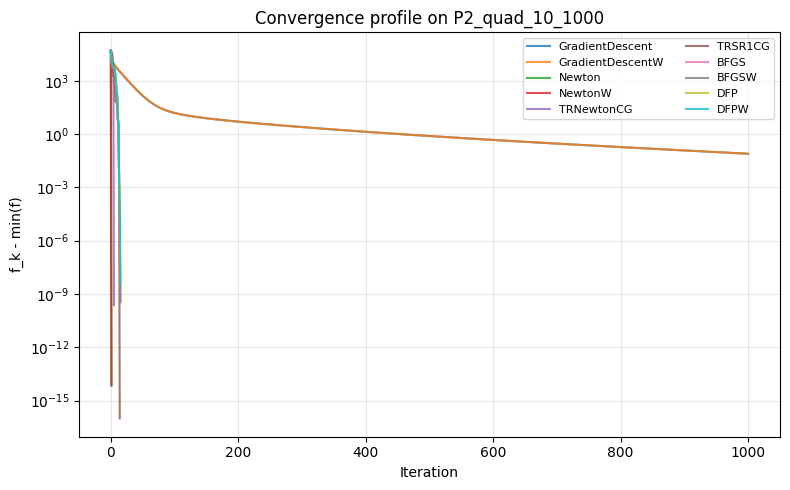

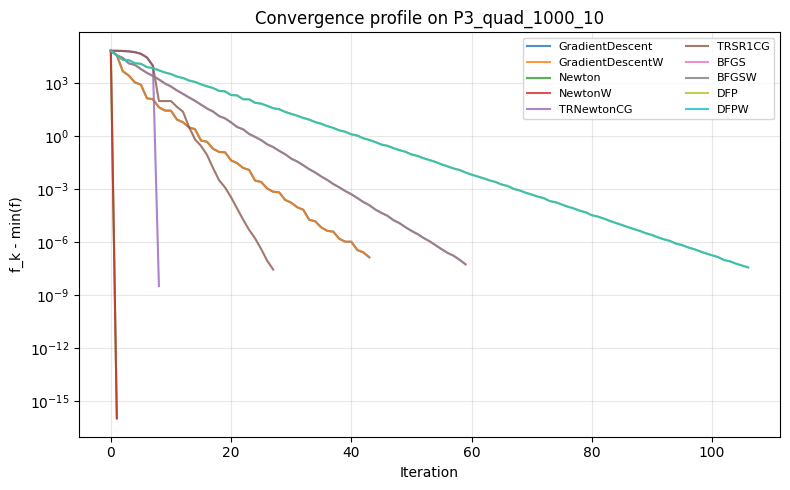

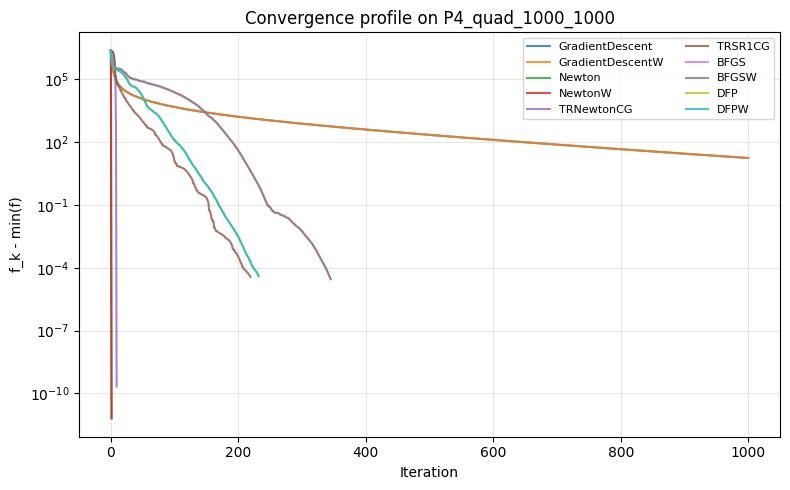

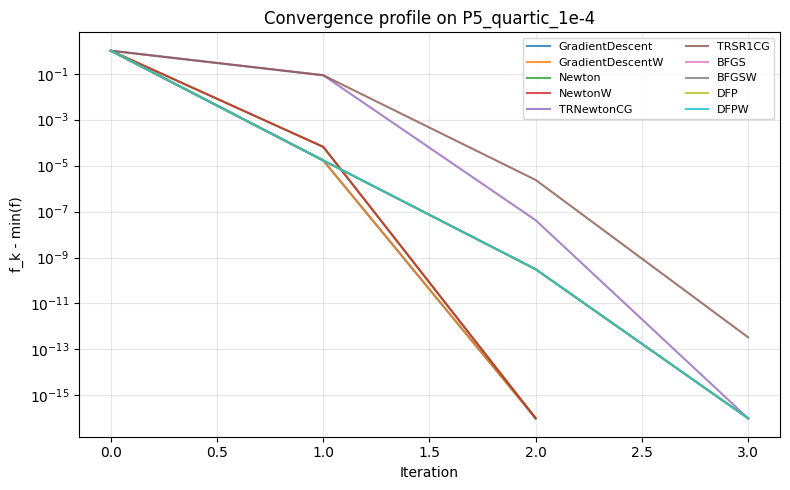

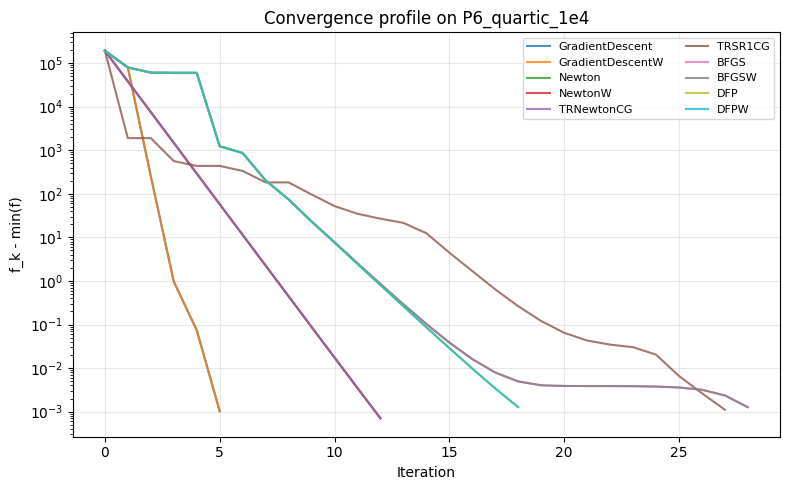

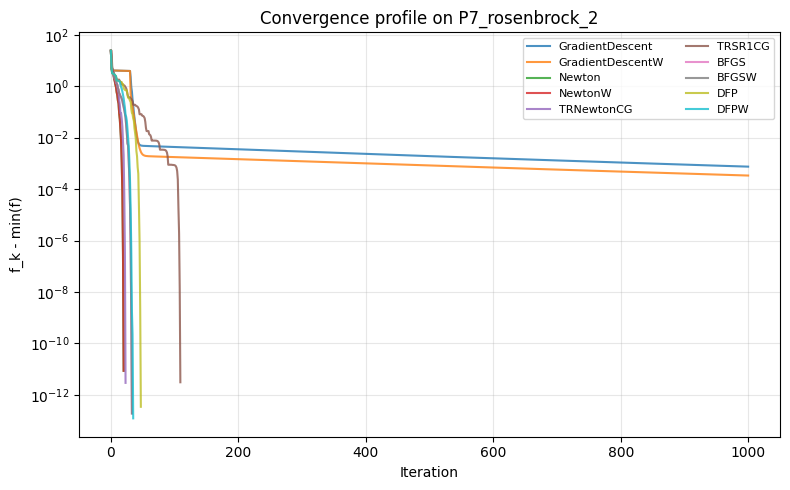

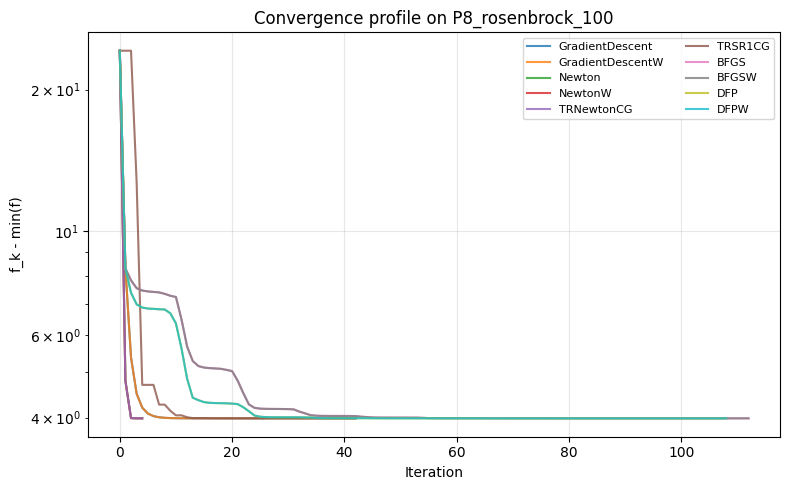

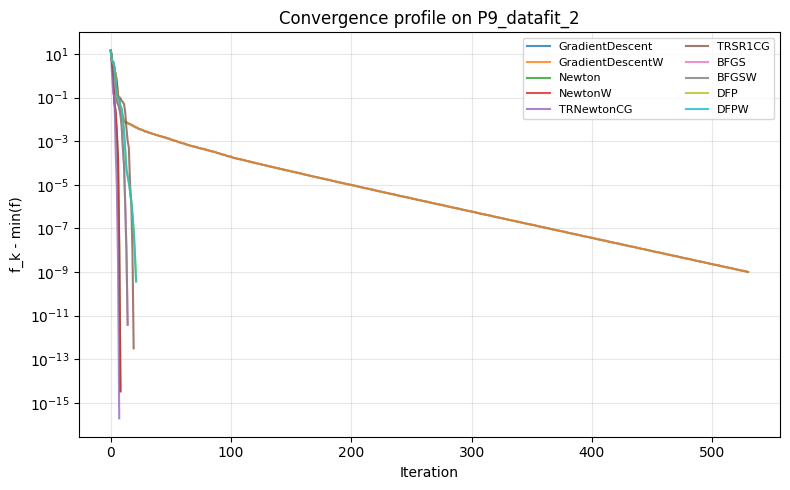

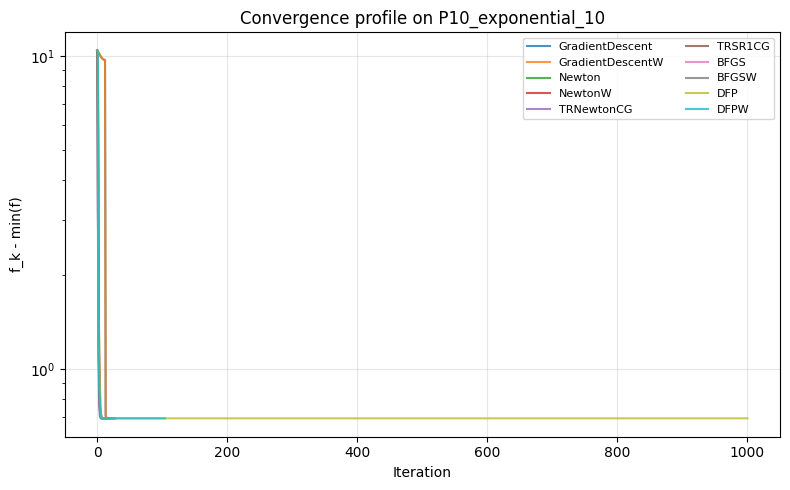

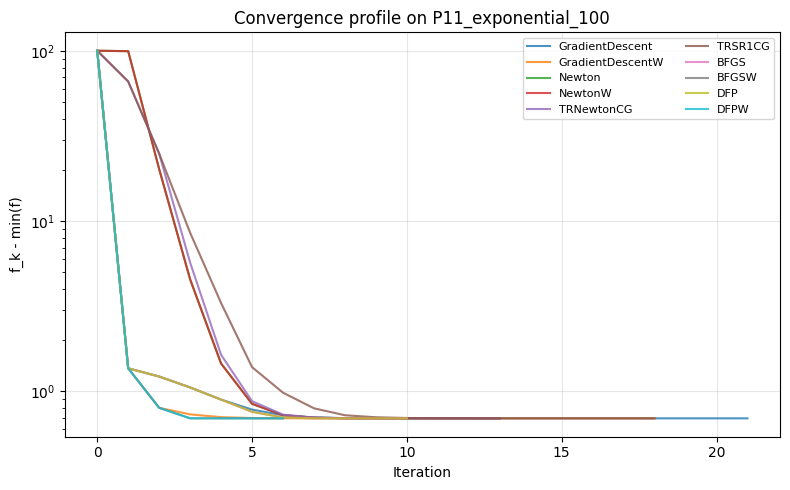

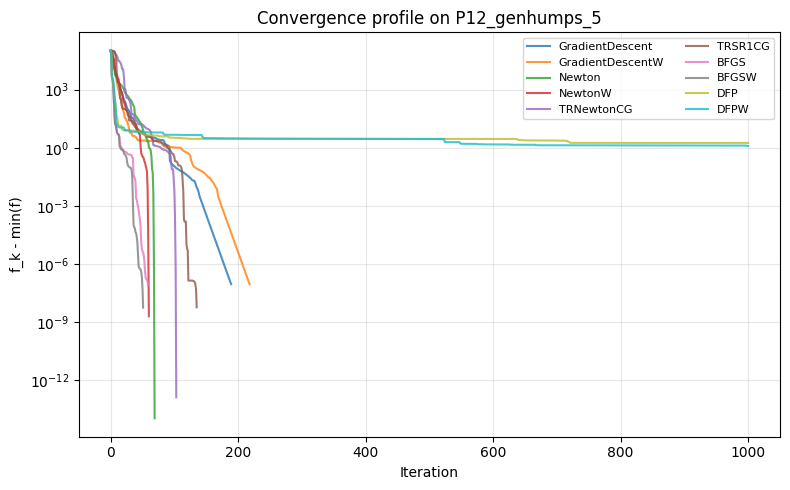

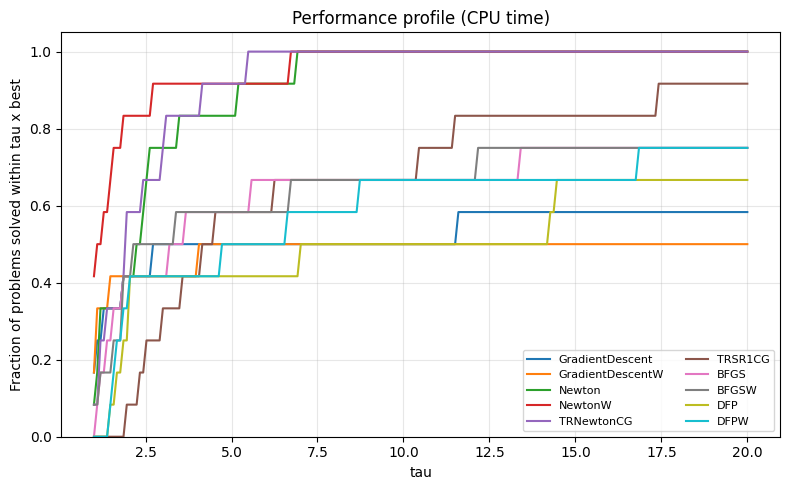

In [5]:
# Optional convenience layer for nicer tables in notebook display.
# If pandas is unavailable, we still keep CSV outputs from previous cell.
try:
    import pandas as pd
except ImportError:
    pd = None

if pd is not None:
    # Flatten results: remove f_hist to keep one scalar per column.
    df = pd.DataFrame([{k: v for k, v in r.items() if k != "f_hist"} for r in results])
    display(df.head(10))

    # Iteration-count pivot table for quick method-vs-problem comparison.
    print("\nSummary table (iterations):")
    display(df.pivot(index="problem", columns="method", values="iterations"))

    # Representative convergence plots: log scale of objective gap.
    # We use three characteristic problems to visualize behavior differences.
    selected_problems = ["P1_quad_10_10", "P2_quad_10_1000", "P3_quad_1000_10", "P4_quad_1000_1000", "P5_quartic_1e-4", "P6_quartic_1e4", "P7_rosenbrock_2", "P8_rosenbrock_100", "P9_datafit_2", "P10_exponential_10", "P11_exponential_100", "P12_genhumps_5"]

    for p_name in selected_problems:
        plt.figure(figsize=(8, 5))
        for r in results:
            if r["problem"] == p_name and r["status"] == "ok" and len(r["f_hist"]) > 1:
                f_hist = np.array(r["f_hist"], dtype=float)
                # Shift by min(f) and clamp for stable log plotting.
                plt.semilogy(np.maximum(f_hist - get_f_star(p_name), 1e-16), label=r["method"], alpha=0.8)
        plt.title(f"Convergence profile on {p_name}")
        plt.xlabel("Iteration")
        plt.ylabel("f_k - min(f)")
        plt.legend(fontsize=8, ncol=2)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Performance profile based on CPU-time ratio to the best solver on each problem.
    ok_df = df[df["status"] == "ok"].copy()
    grouped = ok_df.groupby("problem")
    best_time = grouped["cpu_sec"].min().to_dict()

    method_to_ratios = {m: [] for m in METHODS}
    for _, row in ok_df.iterrows():
        bt = best_time[row["problem"]]
        ratio = row["cpu_sec"] / bt if bt > 0 else np.inf
        method_to_ratios[row["method"]].append(ratio)

    taus = np.linspace(1.0, 20.0, 200)
    plt.figure(figsize=(8, 5))
    total_problems = len(PROBLEM_SPECS)
    for m in METHODS:
        ratios = np.array(method_to_ratios[m], dtype=float)
        if len(ratios) == 0:
            continue
        profile = [np.sum(ratios <= t) / total_problems for t in taus]
        plt.plot(taus, profile, label=m)

    plt.title("Performance profile (CPU time)")
    plt.xlabel("tau")
    plt.ylabel("Fraction of problems solved within tau x best")
    plt.ylim(0.0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print("pandas is not installed. CSV is generated; use it to build tables/plots externally.")

,problem,method,status,iterations,f_eval,g_eval,h_eval,cpu_sec,f_final,grad_inf,error
0,P1_quad_10_10,GradientDescent,ok,44,149,150,0,0.002186,-71.42913,3.165100e-05,
1,P1_quad_10_10,GradientDescentW,ok,44,149,150,0,0.004413,-71.42913,3.165100e-05,
2,P1_quad_10_10,Newton,ok,1,2,3,1,0.000473,-71.42913,1.598721e-14,
3,P1_quad_10_10,NewtonW,ok,1,2,3,1,0.000190,-71.42913,1.598721e-14,
4,P1_quad_10_10,TRNewtonCG,ok,5,6,7,5,0.001038,-71.42913,8.881784e-15,
5,P1_quad_10_10,TRSR1CG,ok,10,11,12,0,0.001977,-71.42913,3.540217e-07,
6,P1_quad_10_10,BFGS,ok,16,25,26,0,0.001044,-71.42913,1.917529e-05,
7,P1_quad_10_10,BFGSW,ok,16,25,26,0,0.001268,-71.42913,1.917529e-05,
8,P1_quad_10_10,DFP,ok,16,22,23,0,0.001328,-71.42913,5.549135e-06,
9,P1_quad_10_10,DFPW,ok,16,22,23,0,0.000890,-71.42913,5.549135e-06,



Summary table (iterations):


method,BFGS,BFGSW,DFP,DFPW,GradientDescent,GradientDescentW,Newton,NewtonW,TRNewtonCG,TRSR1CG
problem,,,,,,,,,,
P10_exponential_10,19,23,1000,104,27,27,13,13,12,17
P11_exponential_100,10,6,10,6,21,18,13,13,13,18
P12_genhumps_5,59,51,1000,1000,189,218,69,60,103,135
P1_quad_10_10,16,16,16,16,44,44,1,1,5,10
P2_quad_10_1000,15,15,15,15,1000,1000,1,1,5,14
P3_quad_1000_10,59,59,106,106,43,43,1,1,8,27
P4_quad_1000_1000,345,345,232,232,1000,1000,1,1,9,219
P5_quartic_1e-4,3,3,3,3,2,2,2,2,3,3
P6_quartic_1e4,28,28,18,18,5,5,12,12,12,27


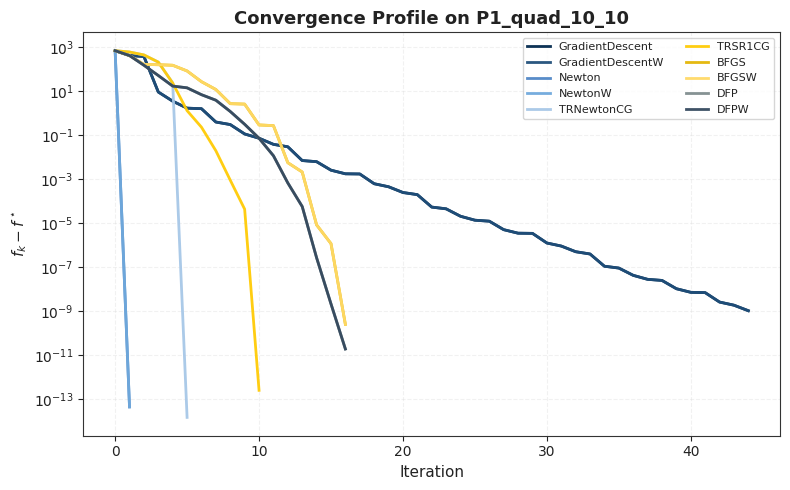

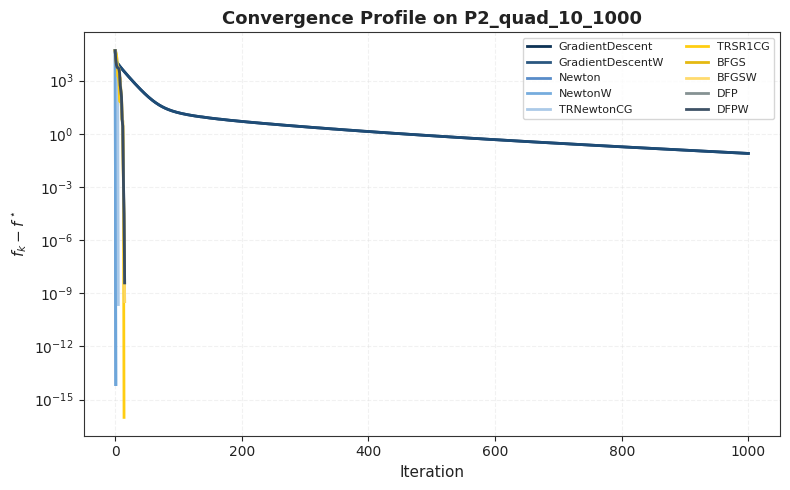

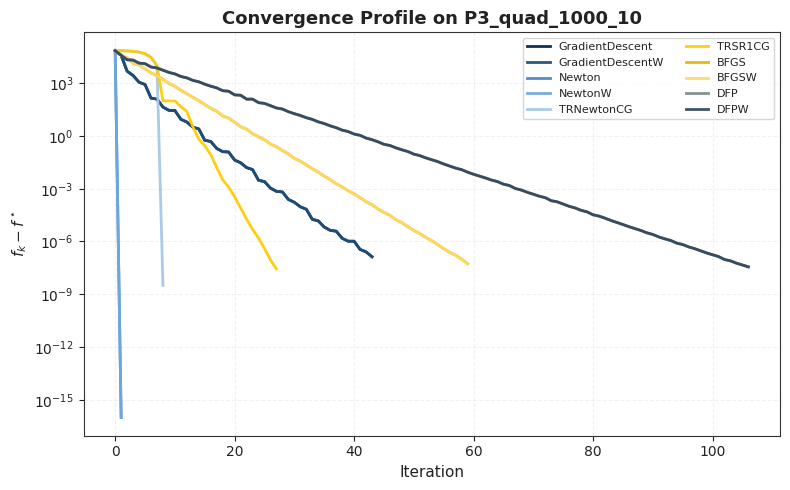

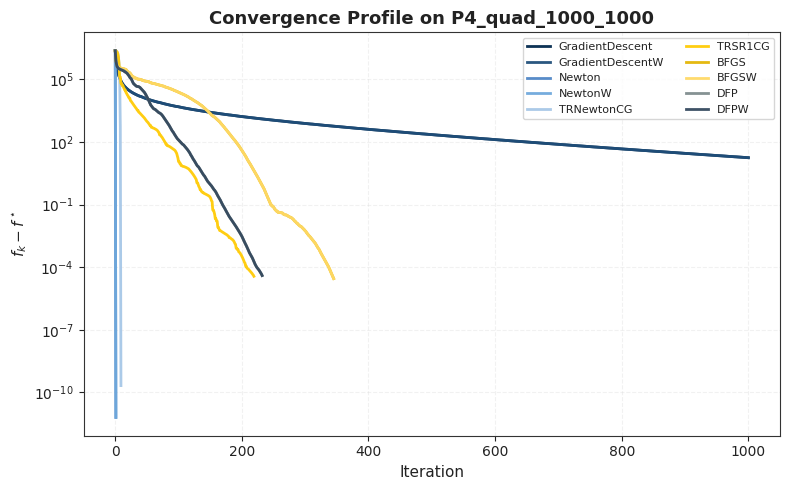

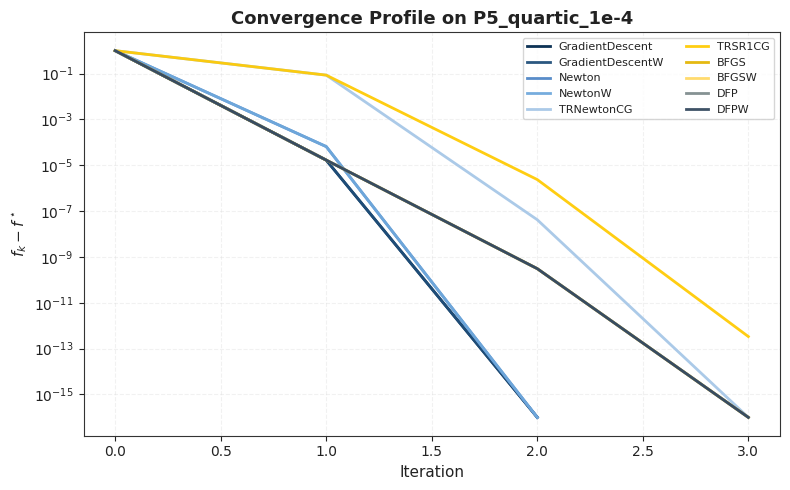

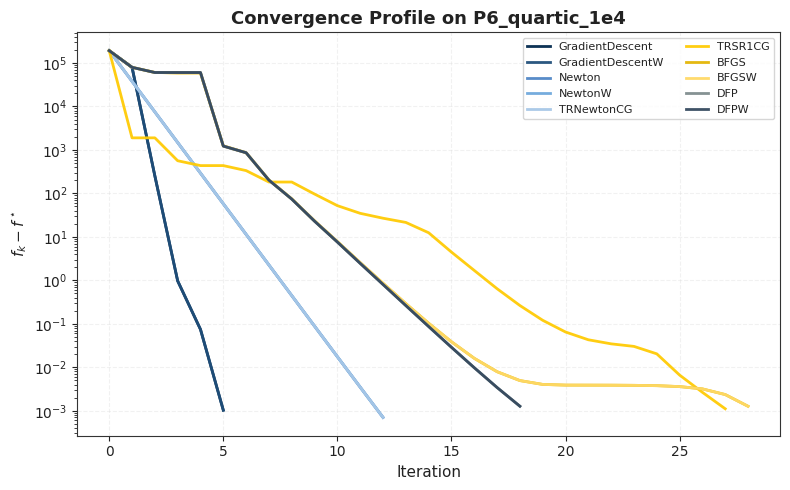

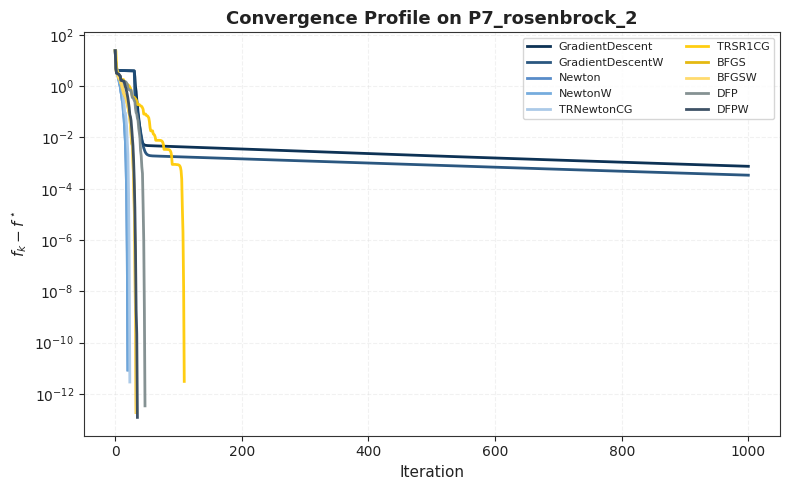

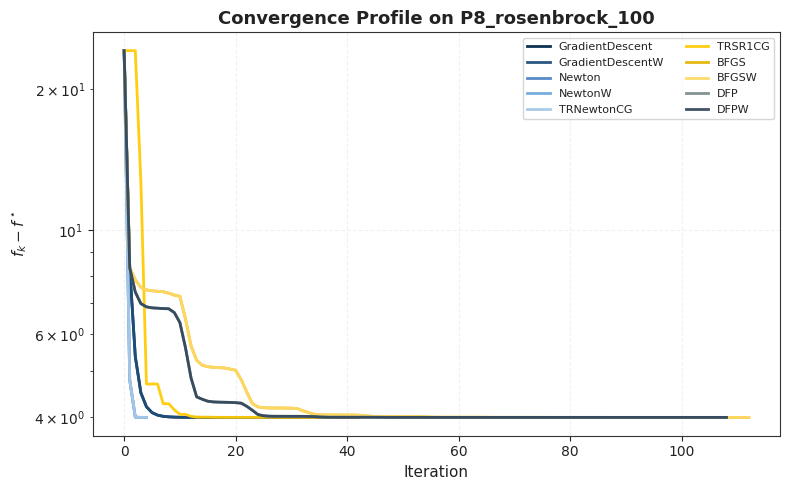

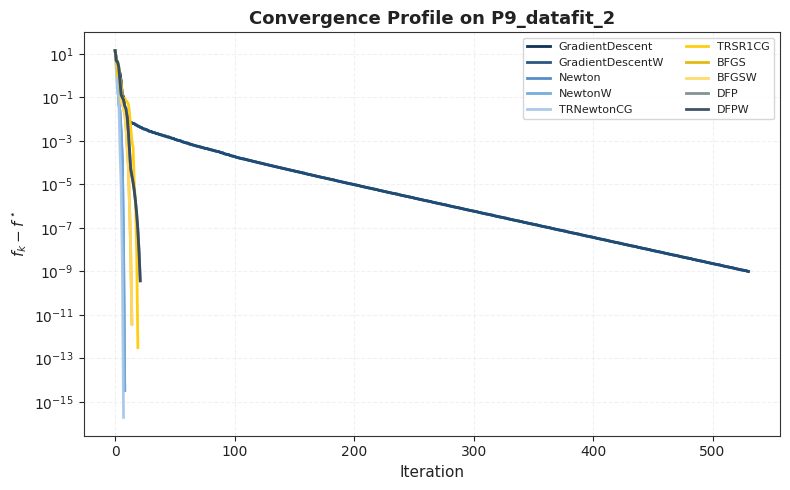

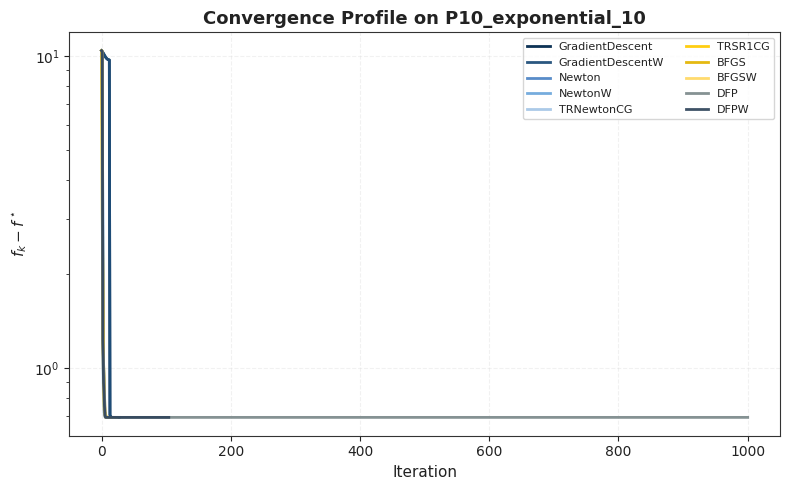

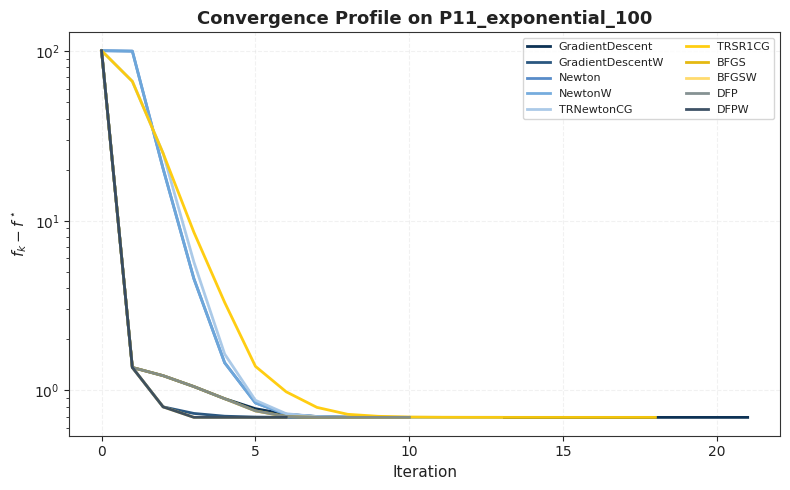

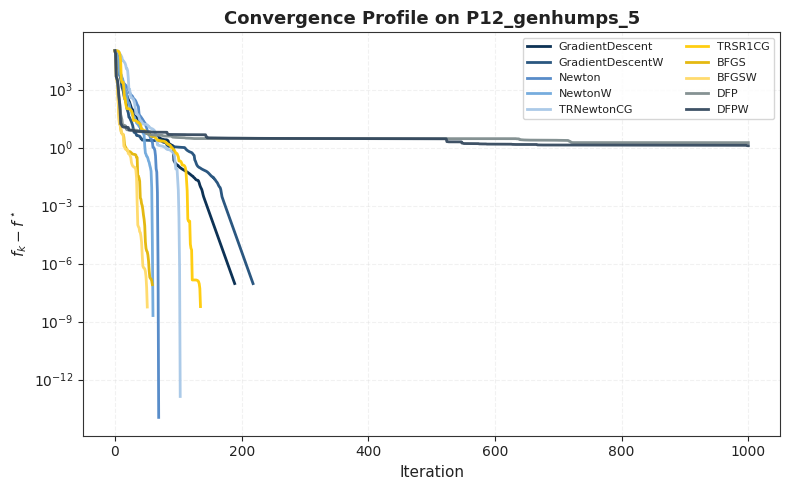

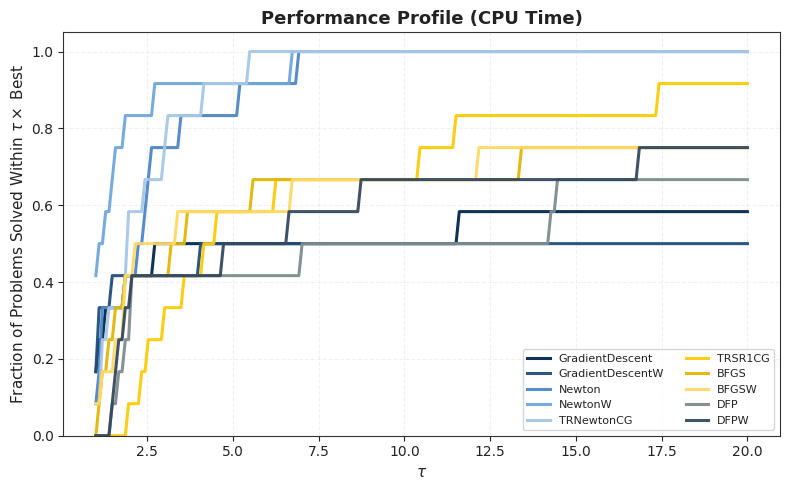

All figures saved to: algorithm_performance


In [6]:
import os
import re

output_dir = "algorithm_performance" # save the output images to this folder
os.makedirs(output_dir, exist_ok=True)

# =========================
# Blue-maize style palette
# blend:#00274C,#1F4E79,#FFCB05
# =========================
um_palette = [
    "#00274C",  # Michigan blue (dark)
    "#1F4E79",  # medium blue
    "#4F86C6",  # lighter blue
    "#6FA8DC",  # soft blue
    "#A7C7E7",  # pale blue
    "#FFCB05",  # maize
    "#E3B505",  # darker maize
    "#FFD966",  # light maize
    "#7F8C8D",  # neutral gray
    "#34495E",  # blue-gray
    "#5D6D7E",  # muted steel
    "#BFC9CA",  # light neutral
]

# map each method to a fixed color for consistency across all plots
method_colors = {m: um_palette[i % len(um_palette)] for i, m in enumerate(METHODS)}

# consistent plotting style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "text.color": "#222222",
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "#CCCCCC",
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "axes.titleweight": "semibold",
})

def safe_name(s):
    """Make filenames safe."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

if pd is not None:
    # Flatten results: remove f_hist to keep one scalar per column.
    df = pd.DataFrame([{k: v for k, v in r.items() if k != "f_hist"} for r in results])
    display(df.head(10))

    # Iteration-count pivot table for quick method-vs-problem comparison.
    print("\nSummary table (iterations):")
    display(df.pivot(index="problem", columns="method", values="iterations"))

    # Representative convergence plots: log scale of objective gap.
    selected_problems = [
        "P1_quad_10_10", "P2_quad_10_1000", "P3_quad_1000_10", "P4_quad_1000_1000",
        "P5_quartic_1e-4", "P6_quartic_1e4", "P7_rosenbrock_2", "P8_rosenbrock_100",
        "P9_datafit_2", "P10_exponential_10", "P11_exponential_100", "P12_genhumps_5"
    ]

    for p_name in selected_problems:
        plt.figure(figsize=(8, 5))

        for r in results:
            if r["problem"] == p_name and r["status"] == "ok" and len(r["f_hist"]) > 1:
                f_hist = np.array(r["f_hist"], dtype=float)
                yvals = np.maximum(f_hist - get_f_star(p_name), 1e-16)

                plt.semilogy(
                    yvals,
                    label=r["method"],
                    color=method_colors.get(r["method"], "#00274C"),
                    linewidth=2.0,
                    alpha=0.95
                )

        plt.title(f"Convergence Profile on {p_name}", fontsize=13)
        plt.xlabel("Iteration", fontsize=11)
        plt.ylabel(r"$f_k - f^\star$", fontsize=11)
        plt.grid(True)
        plt.legend(fontsize=8, ncol=2)
        plt.tight_layout()

        save_path = os.path.join(output_dir, f"{safe_name(p_name)}_convergence.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    # Performance profile based on CPU-time ratio to the best solver on each problem.
    ok_df = df[df["status"] == "ok"].copy()
    grouped = ok_df.groupby("problem")
    best_time = grouped["cpu_sec"].min().to_dict()

    method_to_ratios = {m: [] for m in METHODS}
    for _, row in ok_df.iterrows():
        bt = best_time[row["problem"]]
        ratio = row["cpu_sec"] / bt if bt > 0 else np.inf
        method_to_ratios[row["method"]].append(ratio)

    taus = np.linspace(1.0, 20.0, 200)
    plt.figure(figsize=(8, 5))

    for m in METHODS:
        ratios = np.array(method_to_ratios[m], dtype=float)
        if len(ratios) == 0:
            continue

        profile = [np.sum(ratios <= t) / len(PROBLEM_SPECS) for t in taus]
        plt.plot(
            taus,
            profile,
            label=m,
            color=method_colors.get(m, "#00274C"),
            linewidth=2.2,
            alpha=0.95
        )

    plt.title("Performance Profile (CPU Time)", fontsize=13)
    plt.xlabel(r"$\tau$", fontsize=11)
    plt.ylabel("Fraction of Problems Solved Within " + r"$\tau \times$ Best", fontsize=11)
    plt.ylim(0.0, 1.05)
    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    save_path = os.path.join(output_dir, "performance_profile_cpu_time.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"All figures saved to: {output_dir}")

else:
    print("pandas is not installed. CSV is generated; use it to build tables/plots externally.")

Saved sensitivity table to: /Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/codespace/phase2_c1_c2_sensitivity.csv


/Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/codespace/functions.py:100: RuntimeWarning: overflow encountered in exp
  term2 = 0.1 * np.exp(-x[0])
/Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/codespace/functions.py:109: RuntimeWarning: overflow encountered in exp
  g[0] = (2 * expx / (denom**2)) - 0.1 * np.exp(-x[0])


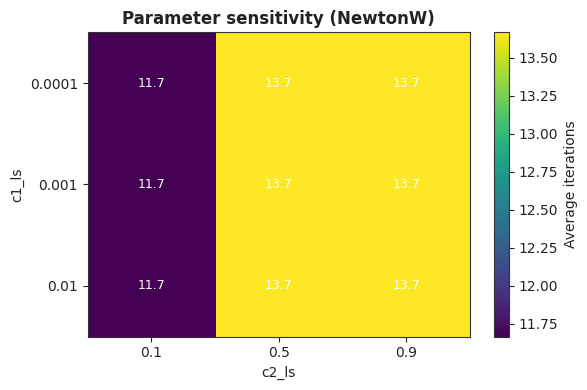

In [7]:
# Big-question study: sensitivity of Wolfe parameters (c1_ls, c2_ls).
# This directly follows the Phase I proposal on line-search parameter tuning.
line_search_methods = ["GradientDescentW", "NewtonW", "BFGSW", "DFPW"]
selected_problem_names = ["P7_rosenbrock_2", "P9_datafit_2", "P10_exponential_10"]
selected_specs = [p for p in PROBLEM_SPECS if p["name"] in selected_problem_names]

# Sweep grid for Armijo (c1) and curvature (c2) constants.
c1_grid = [1e-4, 1e-3, 1e-2]
c2_grid = [0.1, 0.5, 0.9]

sensitivity_rows = []
for method_name in line_search_methods:
    for c1 in c1_grid:
        for c2 in c2_grid:
            iter_list = []
            success_count = 0
            for p in selected_specs:
                method_opts = dict(METHOD_DEFAULTS[method_name])
                method_opts["c1_ls"] = c1
                method_opts["c2_ls"] = c2
                row = run_one_experiment(
                    p,
                    method_name,
                    method_options=method_opts,
                    global_options=GLOBAL_OPTIONS,
                )
                if row["status"] == "ok":
                    success_count += 1
                    iter_list.append(row["iterations"])

            # Store coarse robustness (success_rate) + efficiency (avg_iterations).
            sensitivity_rows.append(
                {
                    "method": method_name,
                    "c1_ls": c1,
                    "c2_ls": c2,
                    "success_rate": success_count / len(selected_specs),
                    "avg_iterations": float(np.mean(iter_list)) if iter_list else np.nan,
                }
            )

# Export sensitivity table for report appendix/results discussion.
sensitivity_csv = ROOT / "phase2_c1_c2_sensitivity.csv"
with sensitivity_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["method", "c1_ls", "c2_ls", "success_rate", "avg_iterations"],
    )
    writer.writeheader()
    writer.writerows(sensitivity_rows)

print(f"Saved sensitivity table to: {sensitivity_csv}")

# Heatmap: quick visual for one representative method.
target_method = "NewtonW"
heat = np.full((len(c1_grid), len(c2_grid)), np.nan)
for i, c1 in enumerate(c1_grid):
    for j, c2 in enumerate(c2_grid):
        vals = [
            r["avg_iterations"]
            for r in sensitivity_rows
            if r["method"] == target_method
            and math.isclose(r["c1_ls"], c1)
            and math.isclose(r["c2_ls"], c2)
        ]
        if vals:
            heat[i, j] = vals[0]

plt.figure(figsize=(6, 4))
plt.imshow(heat, cmap="viridis", aspect="auto")
plt.colorbar(label="Average iterations")
plt.xticks(range(len(c2_grid)), [str(v) for v in c2_grid])
plt.yticks(range(len(c1_grid)), [str(v) for v in c1_grid])
plt.xlabel("c2_ls")
plt.ylabel("c1_ls")
plt.title(f"Parameter sensitivity ({target_method})")
for i in range(len(c1_grid)):
    for j in range(len(c2_grid)):
        val = heat[i, j]
        txt = "nan" if not np.isfinite(val) else f"{val:.1f}"
        plt.text(j, i, txt, ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()